### Import Dependencies

In [1]:
import openai
from qdrant_client import QdrantClient, models
from qdrant_client.models import Document, Prefetch

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from IPython.display import Image, display
from typing import Annotated, List
from operator import add
import random
from jinja2 import Template
import instructor
from langsmith import traceable, get_current_run_tree

In [49]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    question_relevant: bool = False
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

In [50]:
class QueryExpandResponse(BaseModel):
    statements: List[str] = Field(description="A list of statements that are related to the original query")

In [51]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model": "gpt-5.4-mini"
    }
)

def query_expansion_node(state: State) -> dict:
    prompt_template = """
    You are a query expansion module in a shopping assistant. Your job is to rewrite the customer's query into distinct statements for semantic search.
    ## Instructions:
    - Expand the customer's query into a list of distinct statements (1 to 5 concise statements)
    - Each statement should capture a separate product or attribute from the query
    - Use natural product description language
    - Do not produce multiple statements that express the same intent

    ## Examples:
    Query: "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
    Statements:
    - tablet for kids
    - watch for adults
    - laptop

    Query: "I need a warm winter jacket for hiking"
    Statements:
    - warm winter jacket
    - hiking outfit for cold weather

    <query>:
    {{query}}
    </query>
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=QueryExpandResponse,
        reasoning={"effort":"none"}
    )
    return {
        'expanded_query': response.statements
    }

In [52]:
def query_expand_conditional_edges(state: State) -> dict:
    send_messages = []
    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )
    return send_messages        

### 1. Retrieval node

In [53]:
@traceable(
    name='embed_query',
    run_type='embedding',
    metadata={
        'ls_provider': 'openai',
        'ls_model_name': 'text-embedding-3-small',
    },
)
def get_embedding(text, model='text-embedding-3-small'):
    response = openai.embeddings.create(
        model=model,
        input=text,
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata['usage_metadata'] = {
            'input_tokens': response.usage.prompt_tokens,
            'total_tokens': response.usage.total_tokens,
        }
    
    return response.data[0].embedding

@traceable(
    name='retriever_node',
    run_type='retriever',
)
def retriever_node(state: State) -> dict:
    qdrant_client = QdrantClient(url='http://localhost:6333')
    query_embedding = get_embedding(state['query'])

    results = qdrant_client.query_points(
        collection_name="amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=state['query'],
                    model="qdrant/bm25",
                ),
                using="bm25",
                limit=20
            )
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
        limit=state['k']
    )

    retrieved_context_ids = []
    retrieved_context_scores = []
    retrieved_context_texts = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload['parent_asin'])
        retrieved_context_scores.append(result.score)
        retrieved_context_texts.append(result.payload['processed_description'])
        retrieved_context_ratings.append(result.payload['average_rating'])
    
    formatted_context = ''

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context_texts, retrieved_context_ratings):
        formatted_context += f"- Product ID: {id}, Product Rating: {rating}, Product Description: {chunk}\n"
    
    return {
        "retrieved_context": [formatted_context]
    }

### 2. Aggregator node

In [54]:
class AggregatorResponse(BaseModel):
    answer: str

In [55]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model": "gpt-5.4-mini"
    }
)

def aggregator_node(state: State) -> dict:
    preprocessed_context = '\n'.join(state.retrieved_context)

    prompt_template = """
    You are a shopping assistant that can answer questions about the products in stock.
      
    You will be given a question and a list of context.

    Instructions:
    - Answer the question based on the context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

    Context:
    {{preprocessed_context}}

    Question:
    {{question}}
    """
    template = Template(prompt_template)
    prompt = template.render(preprocessed_context=preprocessed_context, question=state.initial_query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=AggregatorResponse,
        reasoning={"effort":"none"}
    )
    return {
        'answer': response.answer
    }

### User intent Router Node

In [71]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str = Field(description="An answer to the question if it's not relevant")

In [72]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model": "gpt-5.4-mini"
    }
)

def intent_router_node(state: State) -> dict:
    prompt_template = """
    You are a relevance router for a shopping assistant that answers questions about products in stock. Your goal is to determine whether the question asked by the customer is relevant or not.

    ## Instructions:
    - If the question is about products, availability, pricing, comparisons and product recommendations, label the question as relevant
    - If the question is about store policies, personal advice, or unrelated topics, label the question as not relevant

    <question>
    {{query}}
    </question>
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=IntentRouterResponse,
        reasoning={"effort":"none"}
    )
    return {
        'question_relevant': response.question_relevant,
        'answer': response.answer
    }

In [73]:
def intent_router_conditional_edges(state: State) -> str:
    if state.question_relevant:
        return "query_expansion_node"
    else:
        return "end"

In [74]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node('retriever_node', retriever_node)
workflow.add_node('aggregator_node', aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "query_expansion_node": "query_expansion_node",
        "end": END 
    }
)
workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges
)

workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

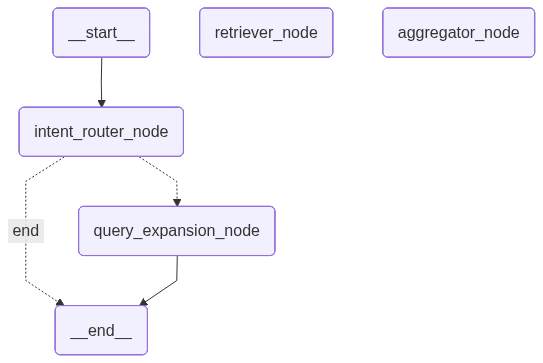

In [75]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [63]:
initial_state = {
    "initial_query": "Can I get a laptop for my wife, a watch for me and a tablet for my kid?"
}

In [64]:
result = graph.invoke(initial_state)

In [67]:
print(result['answer'])

Yes — based on the available products, here are suitable options for each person:

- For your wife: a laptop bag
  - Product ID: B09PVC7RYZ
  - Rating: 4.5
  - Product type: Waterproof PU leather laptop tote bag for women
  - Fits: up to 15.6-inch laptop
  - Includes: 3-piece set with handbag, small makeup bag, and purse
  - Features:
    - Built-in USB charging port for convenient phone charging while on the go
    - Large-capacity design with independent laptop sponge protection compartment
    - Detachable shoulder strap so it can be used as a shoulder bag or tote
    - Many compartments for organized storage
    - Suitable for work, office, school, shopping, business trips, travel, and outdoors

- For you: a smartwatch
  - Product ID: B0BCF3KRMM
  - Rating: 4.0
  - Product type: Military smart watch for men
  - Key features:
    - Bluetooth calling for making and receiving calls
    - 5ATM waterproof rating, suitable for 50 meters underwater
    - Rugged titanium body with metal fr

In [76]:
initial_state = {
    "initial_query": "Is the bus coming from the airport?"
}

In [77]:
result = graph.invoke(initial_state)

In [78]:
print(result['answer'])

Not relevant.
